In [69]:
import json
import pandas as pd

QRELS = {}
YEARS = ['19', '20']
YEAR_TO_TREC = {'19': 'trec28', '20': 'trec29'}
MODELS = [
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic',
    'trec'
]

def correlation(qrels_a, qrels_b, year, method):
    eval_scores = json.load(open('evaluation-scores-per-system.json', 'r'))
    systems = eval_scores[qrels_a][year].keys()
    df = []
    for system in systems:
        df.append({'system': system, 'qrels_a': eval_scores[qrels_a][year][system]['ndcg@10'], 'qrels_b': eval_scores[qrels_b][year][system]['ndcg@10']})
    
    df = pd.DataFrame(df)

    return df[['qrels_a', 'qrels_b']].corr(method=method).iloc[0]['qrels_b']


def report_system_correlations(qrels_a, qrels_b):
    ret = []
    for year in ['19', '20']:
        ret.append(correlation(qrels_a, qrels_b, year, 'kendall'))
        ret.append(correlation(qrels_a, qrels_b, year, 'spearman'))

    ret = ["{:.3f}".format(i) for i in ret]
    return ' & '.join([i.replace('0.', '.') for i in ret])


In [70]:
def table():
    return """\\begin{tabular}{@{}l@{\\hspace{1em}}cc@{\\hspace{1em}}cc@{\\hspace{1em}}cc@{}}
\\toprule
\\bfseries Annotator     &   \\multicolumn{2}{c@{\\hspace{1em}}}{\\bfseries DL 19}  & \\multicolumn{2}{c@{\\hspace{1em}}}{\\bfseries DL 20} & \\multicolumn{2}{c@{\\hspace{1em}}}{\\bfseries Mean} \\\\
\\cmidrule(r@{.5em}){2-3}
\\cmidrule(r@{.5em}){4-5}
\\cmidrule(r@{.5em}){6-7}

& $\\tau$ & $\\rho$ & $\\tau$ & $\\rho$ & $\\tau$ & $\\rho$ \\\\

\\midrule

Claude-3-haiku & """ + report_system_correlations('trec', 'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic') + """ \\\\

Gemini-1.5-flash & """ + report_system_correlations('trec', 'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic') + """ \\\\

Gemini-1.5-flash-8b & """ + report_system_correlations('trec', 'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic') + """ \\\\

GPT-4o & """ + report_system_correlations('trec', 'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic') + """ \\\\

GPT-4o-mini & """ + report_system_correlations('trec', 'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic') + """ \\\\

\\bottomrule

\\end{tabular}"""

print(table())

\begin{tabular}{@{}l@{\hspace{1em}}cc@{\hspace{1em}}cc@{\hspace{1em}}cc@{}}
\toprule
\bfseries Annotator     &   \multicolumn{2}{c@{\hspace{1em}}}{\bfseries DL 19}  & \multicolumn{2}{c@{\hspace{1em}}}{\bfseries DL 20} & \multicolumn{2}{c@{\hspace{1em}}}{\bfseries Mean} \\
\cmidrule(r@{.5em}){2-3}
\cmidrule(r@{.5em}){4-5}
\cmidrule(r@{.5em}){6-7}

& $\tau$ & $\rho$ & $\tau$ & $\rho$ & $\tau$ & $\rho$ \\

\midrule

Claude-3-haiku & .901 & .980 & .898 & .983 \\

Gemini-1.5-flash & .859 & .966 & .937 & .992 \\

Gemini-1.5-flash-8b & .901 & .982 & .861 & .970 \\

GPT-4o & .895 & .977 & .939 & .992 \\

GPT-4o-mini & .901 & .980 & .937 & .992 \\

\bottomrule

\end{tabular}


In [71]:
MODEL_TO_NAME = {
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic': 'Claude-3-haiku',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic': 'Gemini-1.5-flash',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic': 'Gemini-1.5-flash-8b',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic': 'GPT-4o',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic': 'GPT-4o-mini',
}


In [72]:
def pairwise_correlations(year, method):
    df = []
    for a in range(len(MODELS[:-1])):
        for b in range(len(MODELS[:-1])):
            if b > a:
                continue
            model_a, model_b = MODELS[a], MODELS[b]
            df.append({'model_a': MODEL_TO_NAME[model_a], 'model_b': MODEL_TO_NAME[model_b], method: correlation(model_a, model_b, year, method)})
    return pd.DataFrame(df)

pairwise_correlations('19', 'spearman')

,model_a,model_b,spearman
0,Claude-3-haiku,Claude-3-haiku,1.000000
1,GPT-4o,Claude-3-haiku,0.979848
2,GPT-4o,GPT-4o,1.000000
3,GPT-4o-mini,Claude-3-haiku,0.985775
4,GPT-4o-mini,GPT-4o,0.982456
5,GPT-4o-mini,GPT-4o-mini,1.000000
6,Gemini-1.5-flash,Claude-3-haiku,0.978900
7,Gemini-1.5-flash,GPT-4o,0.973210
8,Gemini-1.5-flash,GPT-4o-mini,0.988383
9,Gemini-1.5-flash,Gemini-1.5-flash,1.000000


In [99]:
def plot(year, method):
    fig = sns.heatmap(pairwise_correlations(year, method).pivot(index='model_a', columns='model_b', values=method), annot=True, fmt=".3f").get_figure()
    fig.savefig(f'rank-correlation-{year}-{method}.pdf', bbox_inches='tight')

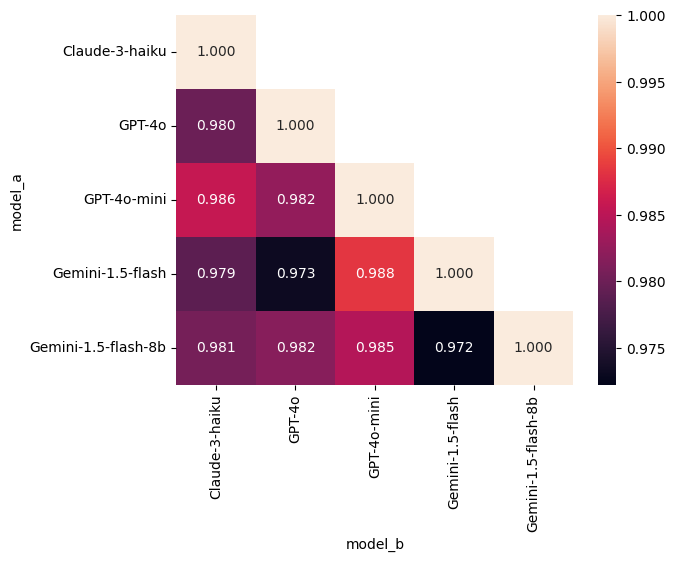

In [100]:
plot('19', 'spearman')

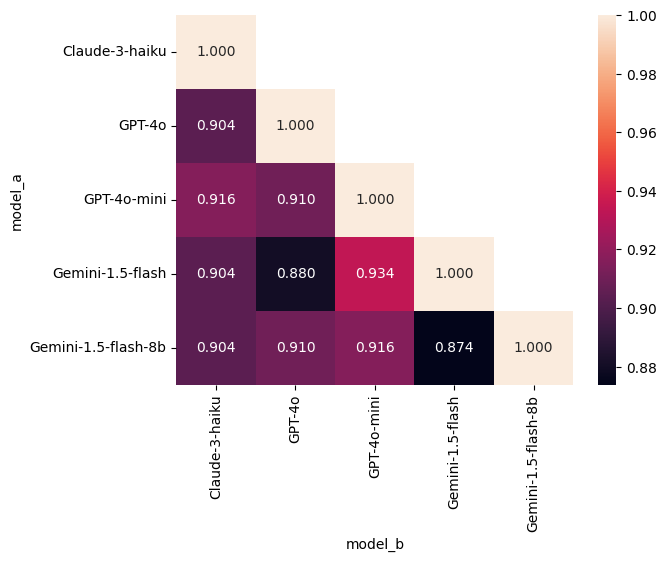

In [101]:
plot('19', 'kendall')

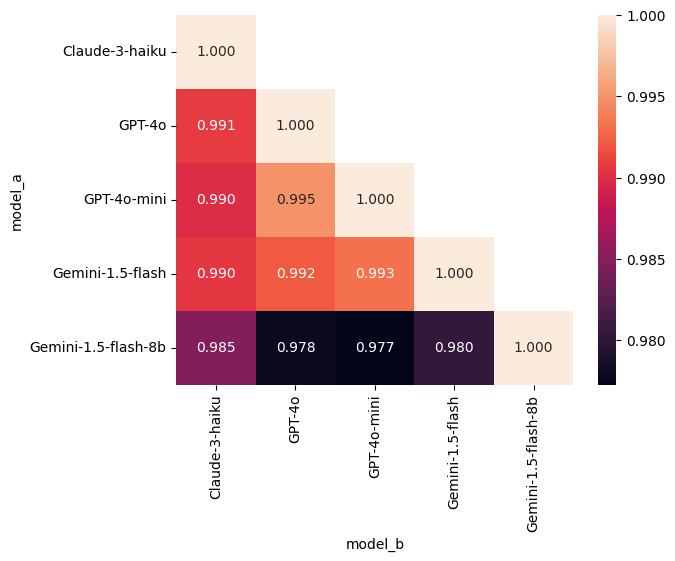

In [102]:
plot('20', 'spearman')

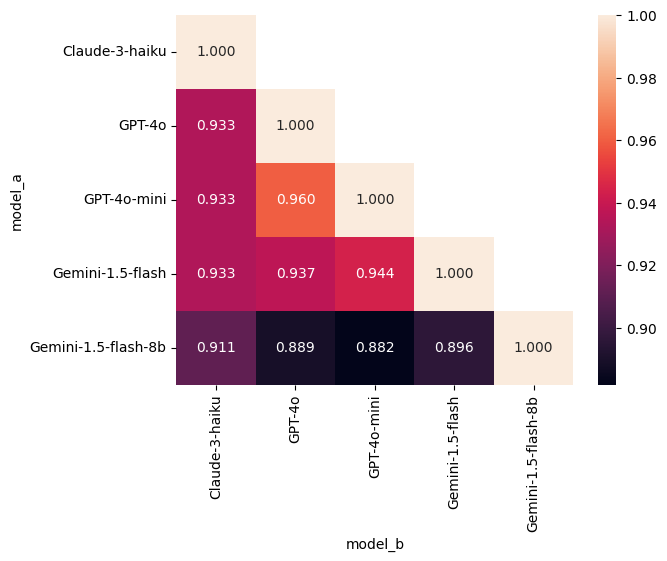

In [103]:
plot('20', 'kendall')

In [104]:
MODELS = [
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic',
    'trec'
]

MODEL_TO_NAME = {
    'AnthropicLLM-claude-3-haiku-20240307-umbrella_zeroshot_basic': 'Claude-3-haiku',
    'GeminiGPT-gemini-1.5-flash-umbrella_zeroshot_basic': 'Gemini-1.5-flash',
    'GeminiGPT-gemini-1.5-flash-8b-umbrella_zeroshot_basic': 'Gemini-1.5-flash-8b',
    'OpenAiGPT-gpt-4o-umbrella_zeroshot_basic': 'GPT-4o',
    'OpenAiGPT-gpt-4o-mini-umbrella_zeroshot_basic': 'GPT-4o-mini',
    'trec': 'Official'
}

In [106]:
def pairwise_rank_correlations(year, method):
    df = []
    for a in range(len(MODELS)):
        for b in range(len(MODELS)):
            if b > a:
                continue
            model_a, model_b = MODELS[a], MODELS[b]
            df.append({'model_a': MODEL_TO_NAME[model_a], 'model_b': MODEL_TO_NAME[model_b], method: correlation(model_a, model_b, year, method)})
    return pd.DataFrame(df)

def agreement_stats(df, v, dataset):
    ret = []
    for _, i in df[(df['model_a'] != df['model_b']) & (df['model_a'] == 'Official')].iterrows():
        ret.append({'Type': 'Human vs. LLM', 'value': i[v]})

    for _, i in df[(df['model_a'] != df['model_b']) & (df['model_a'] != 'Official')].iterrows():
        ret.append({'Type': 'LLM vs. LLM', 'value': i[v]})

    ret = pd.DataFrame(ret)
    ret['measure'] = v
    ret['Dataset'] = 'DL-' + dataset
    return ret    

In [111]:
df19_kendall = pairwise_rank_correlations('19', 'kendall')
df20_kendall = pairwise_rank_correlations('20', 'kendall')
df19_spearman = pairwise_rank_correlations('19', 'spearman')
df20_spearman = pairwise_rank_correlations('20', 'spearman')


df = pd.concat([
    agreement_stats(df19_kendall, 'kendall', '19'),
    agreement_stats(df20_kendall, 'kendall', '20'),
    agreement_stats(df19_spearman, 'spearman', '19'),
    agreement_stats(df20_spearman, 'spearman', '20'),
])

In [113]:
df

,Type,value,measure,Dataset
0,Human vs. LLM,0.900901,kendall,DL-19
1,Human vs. LLM,0.894895,kendall,DL-19
2,Human vs. LLM,0.900901,kendall,DL-19
3,Human vs. LLM,0.858859,kendall,DL-19
4,Human vs. LLM,0.900901,kendall,DL-19
5,LLM vs. LLM,0.903904,kendall,DL-19
6,LLM vs. LLM,0.915916,kendall,DL-19
7,LLM vs. LLM,0.909910,kendall,DL-19
8,LLM vs. LLM,0.903904,kendall,DL-19
9,LLM vs. LLM,0.879880,kendall,DL-19


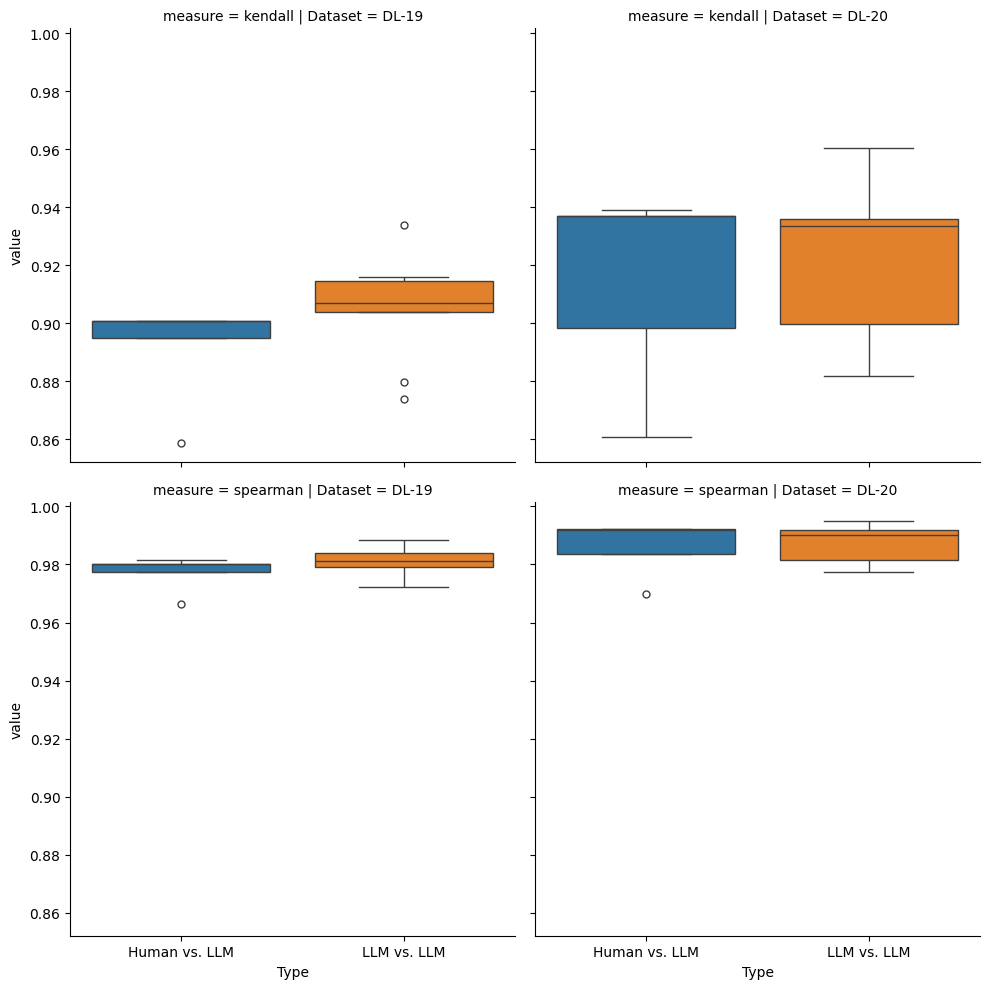

In [114]:
import seaborn as sns

sns.catplot(data=df, x='Type', y='value', hue='Type', col='Dataset', row='measure', kind='box').savefig(f'rank-correlation-overview.pdf', bbox_inches='tight')

# Data Creation

In [20]:
from glob import glob
from tqdm import tqdm
from trectools import TrecRun, TrecQrel, TrecEval
import json

eval_scores = {}

for model in tqdm(MODELS):
    eval_scores[model] = {}
    for year in YEARS:
        eval_scores[model][year] = {}
        qrels = TrecQrel(f'../data/msmarco-passage-trec-dl-20{year}-judged/qrels/{model}.qrels.txt')
        trec_run_dir = f'../data/trec-system-runs/{YEAR_TO_TREC[year]}/deep.passages/'

        for run_name  in glob(trec_run_dir + '*'):
            run = TrecRun(run_name)
            te = TrecEval(run, qrels)
            run_name = run_name.split('/input.')[1].replace('.gz', '')

            eval_scores[model][year][run_name] = {
                'ndcg@10': te.get_ndcg(depth=10)
            }

with open('evaluation-scores-per-system.json', 'w') as f:
    f.write(json.dumps(eval_scores))

100%|██████████| 6/6 [06:55<00:00, 69.24s/it]
